# Degradation stuff

## Imports

In [1]:
import numpy as np
import pandas as pd

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader
from redoxed.plots import GenericPlot, EfficiencyPlot, NyquistPlot
from redoxed import config
config.set_latex_mode(False)  

## Vanadium

C:\Users\es758\AppData\Local\Temp\ipykernel_14300\1497091372.py:67: UserWarning: 'timestamp' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)
C:\Users\es758\AppData\Local\Temp\ipykernel_14300\1497091372.py:67: UserWarning: 'enddate' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)


[90.16288058 90.18610309 90.16296684 90.10987873 90.07455067 89.98341957
 89.95363842 89.92624336 89.94072233 90.00878763 90.00117594 90.01977567
 90.03051662 90.01304579 89.98450635 89.93982064 89.97622011 89.9902076
 89.95742518 89.91941263 89.79558601 89.81083867 89.82611166 89.80468176
 89.77060138 89.66551497 89.70711259 89.677446   89.64266248 89.56898064
 89.4050684  89.3858898  89.37349749 89.33284204 89.31337808 89.14635737
 89.12241809 89.09379016 89.05808545 89.02449166 88.93239031 88.91517482
 88.86009563 88.82276178 88.79612871 88.73747477 88.73967856 88.70721433
 88.65124299 88.64342163 88.64504208 88.65395593 88.61503756 88.55141625
 88.4949122 ]
[88.19738201 88.3045449  88.79647039 89.36242827 89.70191824 89.80074872
 89.94668283 90.03506237 90.06985081]
[89.64842224 89.69800025 89.6910124  89.6635961  89.60855344 89.51907869
 89.52158915 89.63541419 89.73848599 89.76774909 89.71721222 89.75429649
 89.79138949 89.80704331 89.81989256 89.71845462 89.7534993  89.74853821


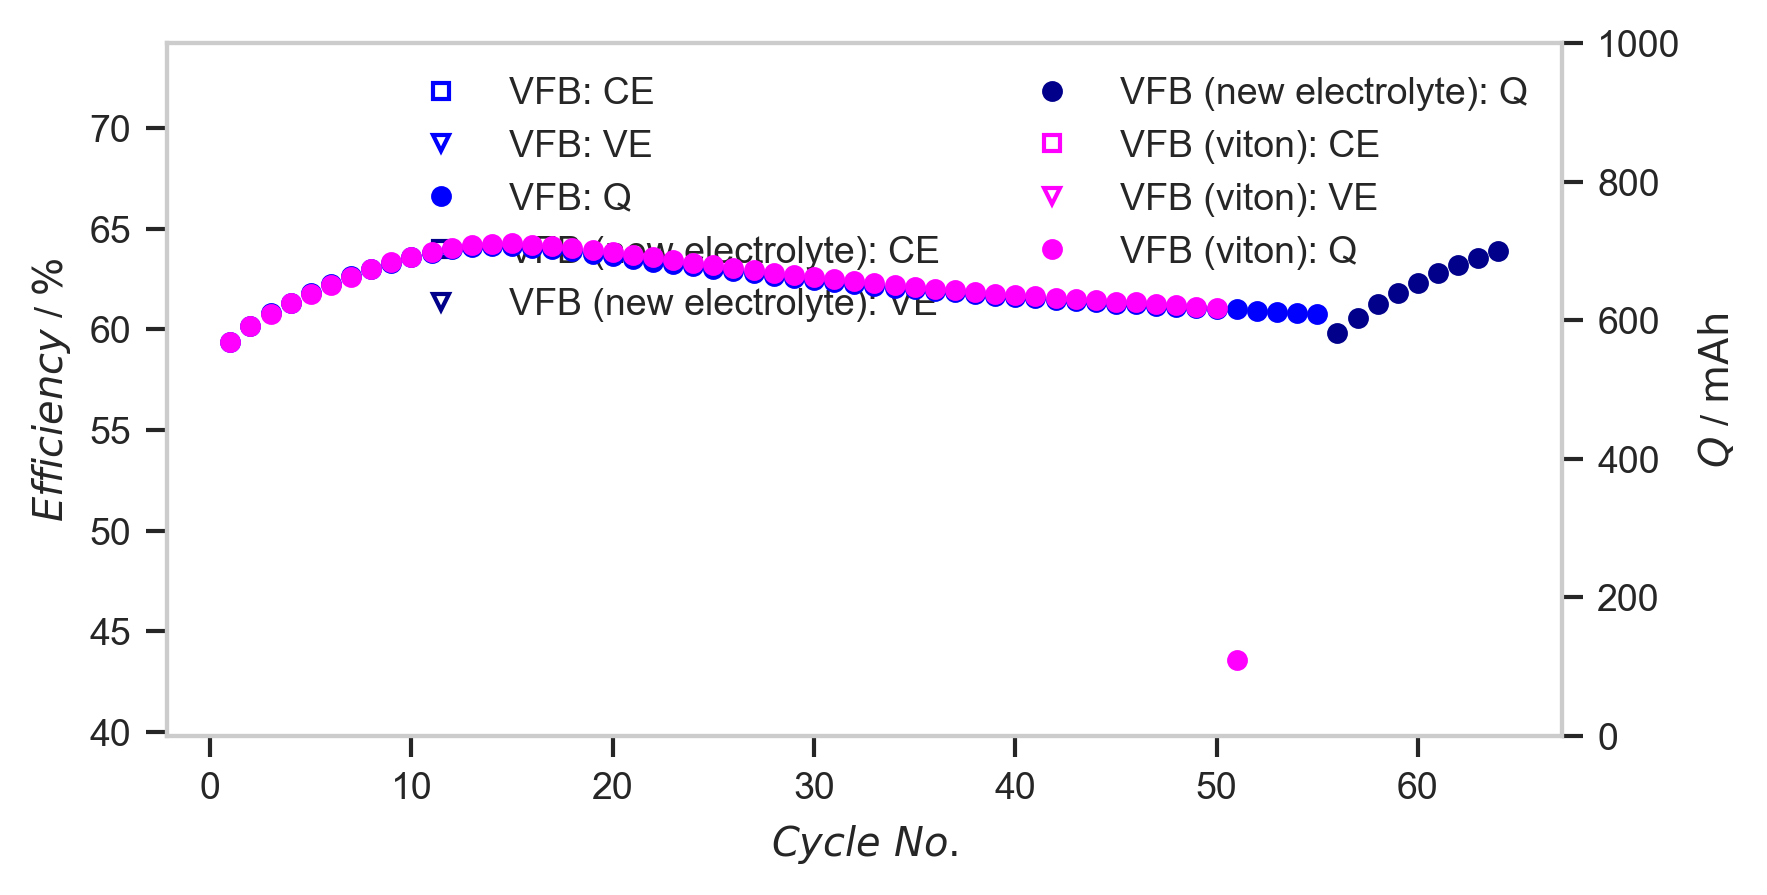

In [3]:
cycling_array = []
color_list = []

j_plot = False
Q_plot = True

EfficiencyPlot_object = EfficiencyPlot(figsize=(6, 3), dpi=300) 


fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\1_VFB_22rpm_06_GCPL_C04.mpr"
label="VFB"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('blue')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\2_VFB_22rpm_elecrepl_06_GCPL_C04.mpr"
label="VFB (new electrolyte)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle and continue cycle count from previous
ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 18)  
ECData_object.df['half cycle']+=110
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('darkblue')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.20 FB2_VFB_NR117_1186HCB400C24h\1_FB2_10mlV_22rpm_1p8V_06_GCPL_C04.mpr"
# label="VFB (1.8 V cutoff)"
# loader = LoaderFactory.get_loader(fpath)
# ECData_object = loader.load_data(fpath=fpath)
# # print(ECData_object.df['half cycle'].unique())
# # remove incomplete cycle
# ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value != 70)  
# CyclingData_object = ECData_object.to_CyclingData()
# CyclingData_object.label = label
# CyclingData_object.set_area(0.0005)  # m2
# cycling_array.append(CyclingData_object)
# color_list.append('orange')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.20 FB2_VFB_NR117_1186HCB400C24h\3_FB2_10mlV_22rpm_1p8V10min_06_GCPL_C04.mpr"
# label="VFB (1.8 V cutoff new electrolyte)"
# loader = LoaderFactory.get_loader(fpath)
# ECData_object = loader.load_data(fpath=fpath)
# print(ECData_object.df['half cycle'].unique())
# # remove incomplete cycle
# ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value != 18)  
# # Continue cycle count from previous
# ECData_object.df['half cycle']+=70
# CyclingData_object = ECData_object.to_CyclingData()
# CyclingData_object.label = label
# CyclingData_object.set_area(0.0005)  # m2
# cycling_array.append(CyclingData_object)
# color_list.append('darkorange')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.09.10 FB2_VFB_viton\1_VFB_22rpm_06_GCPL_C04.mpr"
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\1_VFB_22rpm_06_GCPL_C04.mpr"
label="VFB (viton)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle
#ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 66)  
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('magenta')

for i, CyclingData_object in enumerate(cycling_array):
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    print(CyclingData_object.cycle_data['VE'].to_numpy())
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")
    if Q_plot == True:
        EfficiencyPlot_object.add_Q_discharge(x = CyclingData_object.cycle_data['cycle_number'], Q_discharge = (CyclingData_object.cycle_data['Q_discharge']/3.6), linestyle="", marker="o", markersize = 4, color=color_list[i], label=CyclingData_object.label + ": Q")
if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

if Q_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 1000)

EfficiencyPlot_object.ax.legend(ncols=2)
#EfficiencyPlot_object.ax.set_ylim([80, 100])
#EfficiencyPlot_object.ax.set_xlim([0, None])

display(EfficiencyPlot_object.fig)

C:\Users\es758\AppData\Local\Temp\ipykernel_14300\699565411.py:67: UserWarning: 'timestamp' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)
C:\Users\es758\AppData\Local\Temp\ipykernel_14300\699565411.py:67: UserWarning: 'enddate' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)


[90.16288058 90.18610309 90.16296684 90.10987873 90.07455067 89.98341957
 89.95363842 89.92624336 89.94072233 90.00878763 90.00117594 90.01977567
 90.03051662 90.01304579 89.98450635 89.93982064 89.97622011 89.9902076
 89.95742518 89.91941263 89.79558601 89.81083867 89.82611166 89.80468176
 89.77060138 89.66551497 89.70711259 89.677446   89.64266248 89.56898064
 89.4050684  89.3858898  89.37349749 89.33284204 89.31337808 89.14635737
 89.12241809 89.09379016 89.05808545 89.02449166 88.93239031 88.91517482
 88.86009563 88.82276178 88.79612871 88.73747477 88.73967856 88.70721433
 88.65124299 88.64342163 88.64504208 88.65395593 88.61503756 88.55141625
 88.4949122 ]
[89.51604305 89.57165479 89.58949314 89.57925806 89.5593554  89.47416106
 89.44955635 89.49757692 89.51231796 89.47037368 89.05288996 88.98595652
 89.13100958 89.44046912 89.45912125 89.33389291 89.2935288  89.24613487
 89.19115336 89.14716566 89.02740131 88.99718739 88.98849347 88.91890099
 88.89058507 88.77947387 88.75654558 8

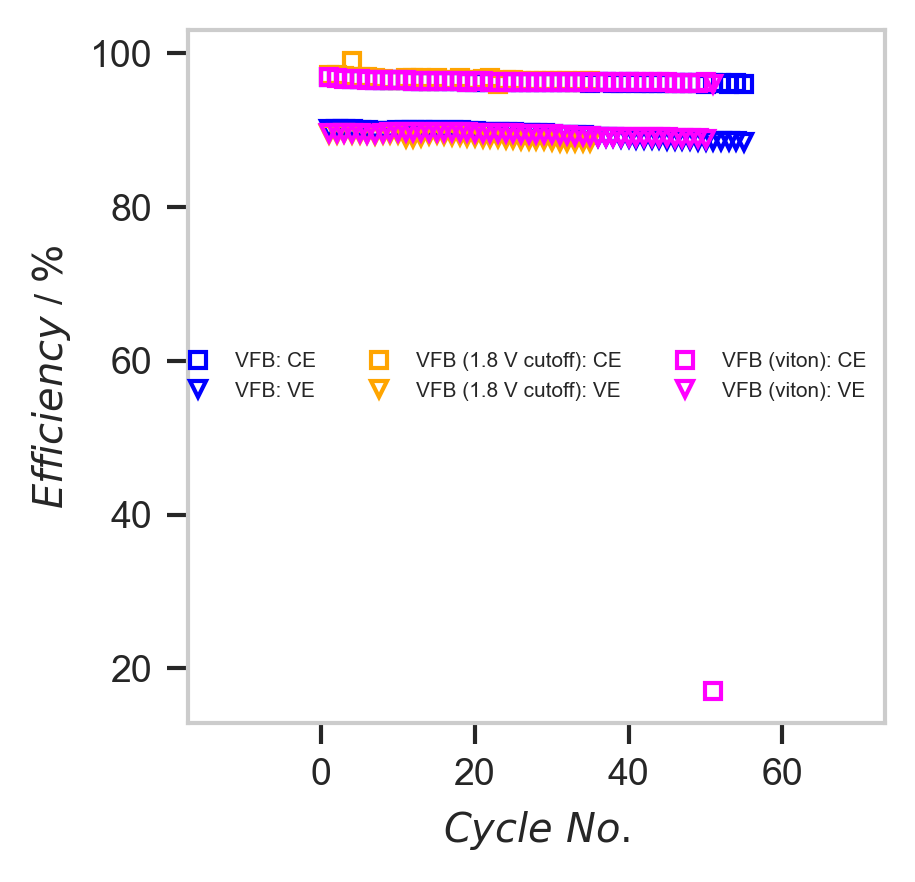

In [6]:
cycling_array = []
color_list = []

j_plot = False
Q_plot = False

EfficiencyPlot_object = EfficiencyPlot(figsize=(3, 3), dpi=300) 


fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\1_VFB_22rpm_06_GCPL_C04.mpr"
label="VFB"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('blue')

# fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\2_VFB_22rpm_elecrepl_06_GCPL_C04.mpr"
# label="VFB (new electrolyte)"
# loader = LoaderFactory.get_loader(fpath)
# ECData_object = loader.load_data(fpath=fpath)
# #print(ECData_object.df['half cycle'].unique())
# # remove incomplete cycle and continue cycle count from previous
# ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 18)  
# ECData_object.df['half cycle']+=110
# CyclingData_object = ECData_object.to_CyclingData()
# CyclingData_object.label = label
# CyclingData_object.set_area(0.0005)  # m2
# cycling_array.append(CyclingData_object)
# color_list.append('darkblue')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.20 FB2_VFB_NR117_1186HCB400C24h\1_FB2_10mlV_22rpm_1p8V_06_GCPL_C04.mpr"
label="VFB (1.8 V cutoff)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
# print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle
ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value != 70)  
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('orange')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.20 FB2_VFB_NR117_1186HCB400C24h\3_FB2_10mlV_22rpm_1p8V10min_06_GCPL_C04.mpr"
# label="VFB (1.8 V cutoff new electrolyte)"
# loader = LoaderFactory.get_loader(fpath)
# ECData_object = loader.load_data(fpath=fpath)
# print(ECData_object.df['half cycle'].unique())
# # remove incomplete cycle
# ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value != 18)  
# # Continue cycle count from previous
# ECData_object.df['half cycle']+=70
# CyclingData_object = ECData_object.to_CyclingData()
# CyclingData_object.label = label
# CyclingData_object.set_area(0.0005)  # m2
# cycling_array.append(CyclingData_object)
# color_list.append('darkorange')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.09.10 FB2_VFB_viton\1_VFB_22rpm_06_GCPL_C04.mpr"
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\1_VFB_22rpm_06_GCPL_C04.mpr"
label="VFB (viton)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle
# ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 66)  
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('magenta')

for i, CyclingData_object in enumerate(cycling_array):
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    print(CyclingData_object.cycle_data['VE'].to_numpy())
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")
    if Q_plot == True:
        EfficiencyPlot_object.add_Q_discharge(x = CyclingData_object.cycle_data['cycle_number'], Q_discharge = (CyclingData_object.cycle_data['Q_discharge']/3.6), linestyle="-", marker="", color=color_list[i], label=CyclingData_object.label + " Q")
if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

EfficiencyPlot_object.ax.legend(ncols=3, fontsize = 5)
#EfficiencyPlot_object.ax.set_ylim([80, 100])
# EfficiencyPlot_object.ax.set_xlim([0, 30])

display(EfficiencyPlot_object.fig)

C:\Users\es758\AppData\Local\Temp\ipykernel_12948\2127673564.py:66: UserWarning: 'timestamp' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)
C:\Users\es758\AppData\Local\Temp\ipykernel_12948\2127673564.py:66: UserWarning: 'enddate' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)


[90.16288058 90.18610309 90.16296684 90.10987873 90.07455067 89.98341957
 89.95363842 89.92624336 89.94072233 90.00878763 90.00117594 90.01977567
 90.03051662 90.01304579 89.98450635 89.93982064 89.97622011 89.9902076
 89.95742518 89.91941263 89.79558601 89.81083867 89.82611166 89.80468176
 89.77060138 89.66551497 89.70711259 89.677446   89.64266248 89.56898064
 89.4050684  89.3858898  89.37349749 89.33284204 89.31337808 89.14635737
 89.12241809 89.09379016 89.05808545 89.02449166 88.93239031 88.91517482
 88.86009563 88.82276178 88.79612871 88.73747477 88.73967856 88.70721433
 88.65124299 88.64342163 88.64504208 88.65395593 88.61503756 88.55141625
 88.4949122 ]
[88.19738201 88.3045449  88.79647039 89.36242827 89.70191824 89.80074872
 89.94668283 90.03506237 90.06985081]
[83.30325156 83.07501495 83.03931656 82.97493092 82.93207697 82.65266954
 82.55476029 82.47413947 82.62277931 82.94590788 83.86903115 84.2286931
 84.4472757  84.62948198 84.76581209 84.69012299 84.95575146 85.11904435
 

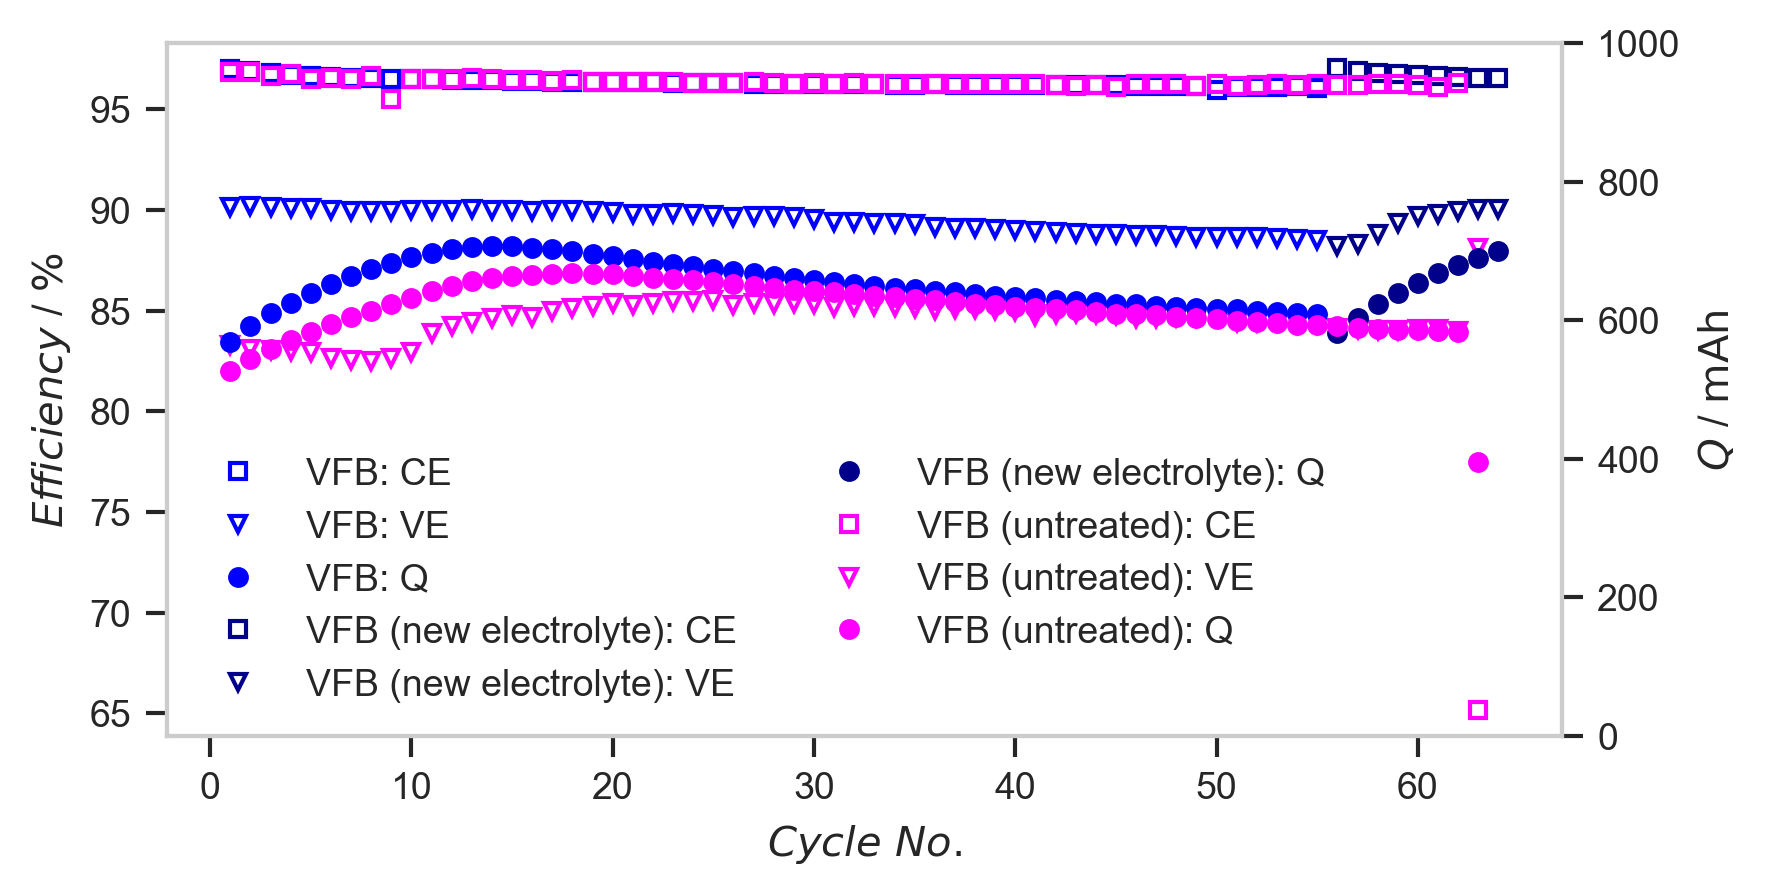

In [2]:

cycling_array = []
color_list = []

j_plot = False
Q_plot = True

EfficiencyPlot_object = EfficiencyPlot(figsize=(6, 3), dpi=300) 


fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\1_VFB_22rpm_06_GCPL_C04.mpr"
label="VFB"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('blue')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\2_VFB_22rpm_elecrepl_06_GCPL_C04.mpr"
label="VFB (new electrolyte)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle and continue cycle count from previous
ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 18)  
ECData_object.df['half cycle']+=110
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('darkblue')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.20 FB2_VFB_NR117_1186HCB400C24h\1_FB2_10mlV_22rpm_1p8V_06_GCPL_C04.mpr"
# label="VFB (1.8 V cutoff)"
# loader = LoaderFactory.get_loader(fpath)
# ECData_object = loader.load_data(fpath=fpath)
# # print(ECData_object.df['half cycle'].unique())
# # remove incomplete cycle
# ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value != 70)  
# CyclingData_object = ECData_object.to_CyclingData()
# CyclingData_object.label = label
# CyclingData_object.set_area(0.0005)  # m2
# cycling_array.append(CyclingData_object)
# color_list.append('orange')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.20 FB2_VFB_NR117_1186HCB400C24h\3_FB2_10mlV_22rpm_1p8V10min_06_GCPL_C04.mpr"
# label="VFB (1.8 V cutoff new electrolyte)"
# loader = LoaderFactory.get_loader(fpath)
# ECData_object = loader.load_data(fpath=fpath)
# print(ECData_object.df['half cycle'].unique())
# # remove incomplete cycle
# ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value != 18)  
# # Continue cycle count from previous
# ECData_object.df['half cycle']+=70
# CyclingData_object = ECData_object.to_CyclingData()
# CyclingData_object.label = label
# CyclingData_object.set_area(0.0005)  # m2
# cycling_array.append(CyclingData_object)
# color_list.append('darkorange')

fpath=r"C:\Users\es758\Downloads\2025.10.16 FB2_VFB_untreated1186HCB\1_20ml_V_NR117_22rpm_06_GCPL_C04.mpr"
label="VFB (untreated)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle
#ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 66)  
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('magenta')

for i, CyclingData_object in enumerate(cycling_array):
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    print(CyclingData_object.cycle_data['VE'].to_numpy())
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")
    if Q_plot == True:
        EfficiencyPlot_object.add_Q_discharge(x = CyclingData_object.cycle_data['cycle_number'], Q_discharge = (CyclingData_object.cycle_data['Q_discharge']/3.6), linestyle="", marker="o", markersize = 4, color=color_list[i], label=CyclingData_object.label + ": Q")
if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

if Q_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 1000)

EfficiencyPlot_object.ax.legend(ncols=2)
#EfficiencyPlot_object.ax.set_ylim([80, 100])
#EfficiencyPlot_object.ax.set_xlim([0, None])

display(EfficiencyPlot_object.fig)

## DHPS

### KOH

[85.31647295 84.89979083 84.69385018 84.49084241 84.40214084 84.30079338
 84.23582127 84.0874451  84.00250637 84.01792534 83.96030257 83.90888051
 83.82017703 83.83375786 83.74391552 83.72808647 83.69784551 83.61356185
 83.56489331 83.5764343  83.70985669 83.70078603 83.65146027 83.68086745
 83.77056758]
[82.30974882 82.20823865 82.18808093 82.06913714 82.05000214 81.98570947
 81.9178349  81.80610413 81.75218284 81.71568465 81.7797444  81.65921422
 81.59384717 81.53842346 81.47749754 81.61052478 81.50018694 81.40904003
 81.38293413 81.35097686 81.5039359  81.45319954 81.42834192 81.34856591
 81.36938771]


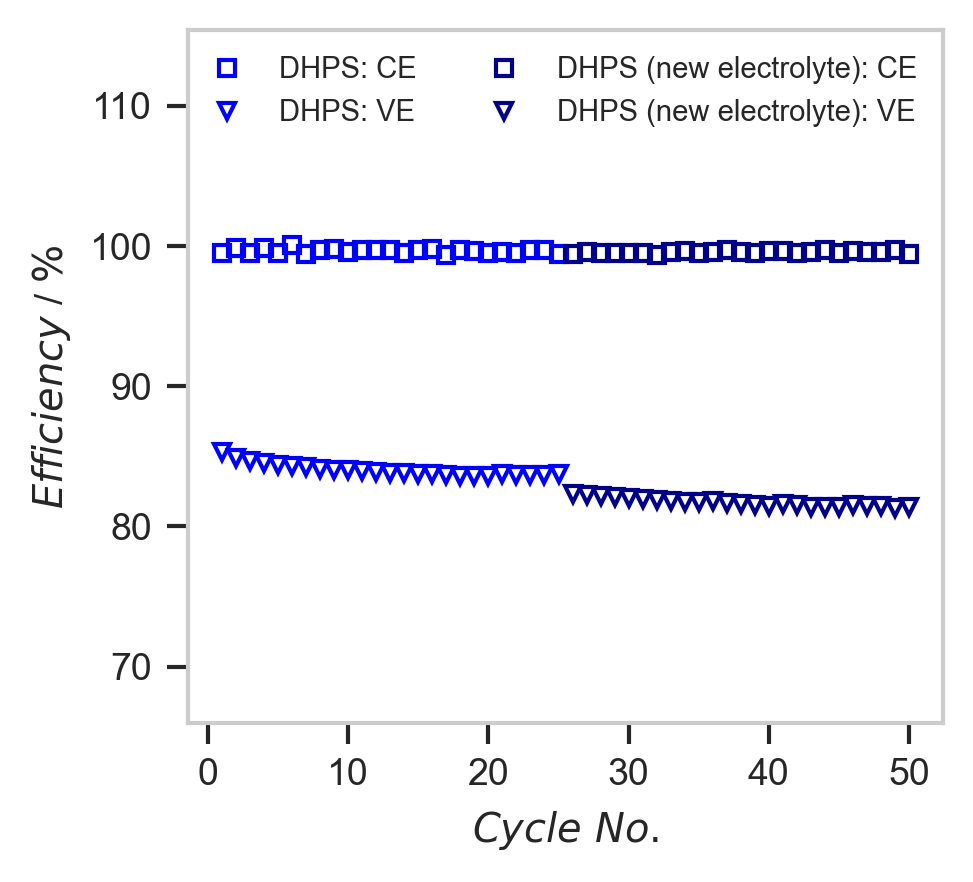

In [22]:
# KOH pristine
r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_04_GCPL_C04.mpr"
# KOH replaced electrolyte
r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\2_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_newelec_04_GCPL_C04.mpr"
# there is then a 0 soc wash and DMSO wash and then emptied and refilled (but under inert)

cycling_array = []
color_list = []

j_plot = False
Q_plot = False

EfficiencyPlot_object = EfficiencyPlot(figsize=(3.25, 3), dpi=300) 


fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_04_GCPL_C04.mpr"
label="DHPS"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('blue')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\2_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_newelec_04_GCPL_C04.mpr"
label="DHPS (new electrolyte)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
ECData_object.df['half cycle']+=25*2
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('darkblue')

for i, CyclingData_object in enumerate(cycling_array):
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    print(CyclingData_object.cycle_data['VE'].to_numpy())
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")
    if Q_plot == True:
        EfficiencyPlot_object.add_Q_discharge(x = CyclingData_object.cycle_data['cycle_number'], Q_discharge = (CyclingData_object.cycle_data['Q_discharge']/3.6), linestyle="", marker="o", markersize = 4, color=color_list[i], label=CyclingData_object.label + ": Q")
if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

if Q_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 1000)

EfficiencyPlot_object.ax.legend(ncols = 2, fontsize = 7)
#EfficiencyPlot_object.ax.set_ylim([80, 100])
#EfficiencyPlot_object.ax.set_xlim([0, None])

display(EfficiencyPlot_object.fig)

15.0
3.0


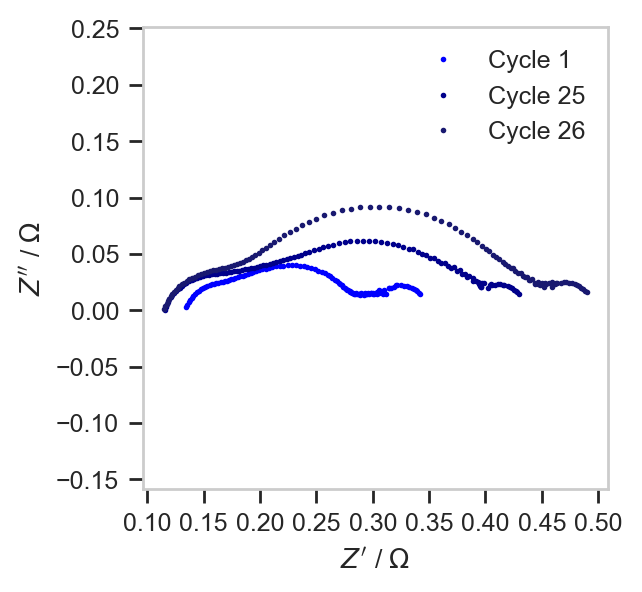

In [42]:
EISData_array = []
fitted_EISData_array = []
DRTData_array = []
R_array = []
L_array = []

lambda_0 = 1e-12

color_list= []

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_02_GEIS_C04.mpr"
label = "Cycle 1"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('blue')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_06_GEIS_C04.mpr"
label = "Cycle 25"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 15) 
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('darkblue')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\2_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_newelec_02_GEIS_C04.mpr"
label = "Cycle 26"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1) 
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('midnightblue')

NyquistPlot_object = NyquistPlot(figsize=(3, 3), dpi=200) 

for i, EISData_object in enumerate(EISData_array):
    EISData_object.trim_inductive()
    #EISData_object.crop_frequency(1, 8e3)
    EISData_object.crop_frequency(0.1, 2e5)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1, color = color_list[i], zorder = 3)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.05)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
NyquistPlot_object.add_major_ticks(spacing_x = 0.05, spacing_y = 0.05)
NyquistPlot_object.ax.legend()

display(NyquistPlot_object.fig)




### NaOH

[84.99749961 84.94235525 84.88301273 84.85399242 84.77077082 84.85859658
 84.81335449 84.78433736 84.73554303 84.73720488 84.77292587 84.76379051
 84.71811939 84.67847465 84.66096325 84.68733176 84.66306642 84.63840879
 84.69283514 84.66289299 84.85644175 84.81706629 84.79815799 84.77533279
 84.80670784]
[84.90286315 84.67753668 85.02050696 84.9690574  84.92417721 84.8898877
 84.80048325 84.72869354 84.75172188 84.70117119 84.69765841 84.58630259
 84.60396528 84.59139953 84.58375912 84.52439892 84.46540412 84.49445423
 84.53577801 84.55637742 84.65479006 84.66318129 84.71558181 84.71595439
 84.77117073]
[88.41335856 88.40470246 88.33507505 88.33651026 88.34547786]


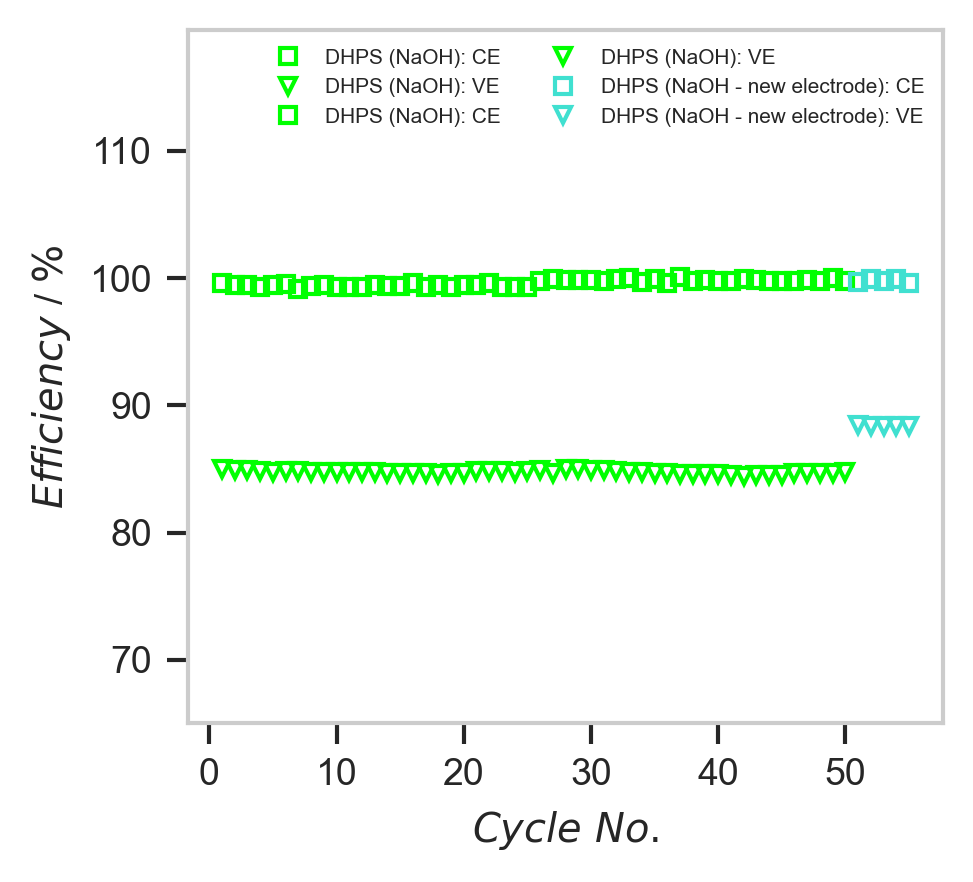

In [57]:
cycling_array = []
color_list = []

j_plot = False

EfficiencyPlot_object = EfficiencyPlot(figsize=(3.25, 3), dpi=300) 

# fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_04_GCPL_C04.mpr"
# label="DHPS (KOH)"
# loader = LoaderFactory.get_loader(fpath)
# ECData_object = loader.load_data(fpath=fpath)
# CyclingData_object = ECData_object.to_CyclingData()
# CyclingData_object.label = label
# CyclingData_object.set_area(0.0005)  # m2
# cycling_array.append(CyclingData_object)
# color_list.append('blue')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\1_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_04_GCPL_C04.mpr"
label="DHPS (NaOH)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('lime')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\2_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_continue_04_GCPL_C04.mpr"
label="DHPS (NaOH)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
# had to get rid of incomplete data
# print(ECData_object.columns)
# print(ECData_object.df['half cycle'].unique())
ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 50)
ECData_object.df['half cycle']+=25*2
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('lime')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\6_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_newnegotrode_04_GCPL_C04.mpr"
label="DHPS (NaOH - new electrode)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
# had to get rid of incomplete data
# print(ECData_object.columns)
# print(ECData_object.df['half cycle'].unique())
#ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 50)
ECData_object.df['half cycle']+=50*2
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('turquoise')


for i, CyclingData_object in enumerate(cycling_array):
    # if CyclingData_object.label == "DHPS (NaOH) 2":
    #     CyclingData_object.label = ""
    #     #EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    print(CyclingData_object.cycle_data['VE'].to_numpy())
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")
    if Q_plot == True:
        EfficiencyPlot_object.add_Q_discharge(x = CyclingData_object.cycle_data['cycle_number'], Q_discharge = (CyclingData_object.cycle_data['Q_discharge']/3.6), linestyle="", marker="o", markersize = 4, color=color_list[i], label=CyclingData_object.label + ": Q")
if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

if Q_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 1000)

EfficiencyPlot_object.ax.legend(ncols = 2, fontsize = 5)
#EfficiencyPlot_object.ax.set_ylim([80, 100])
#EfficiencyPlot_object.ax.set_xlim([0, None])

display(EfficiencyPlot_object.fig)

3.0
15.0
3.0


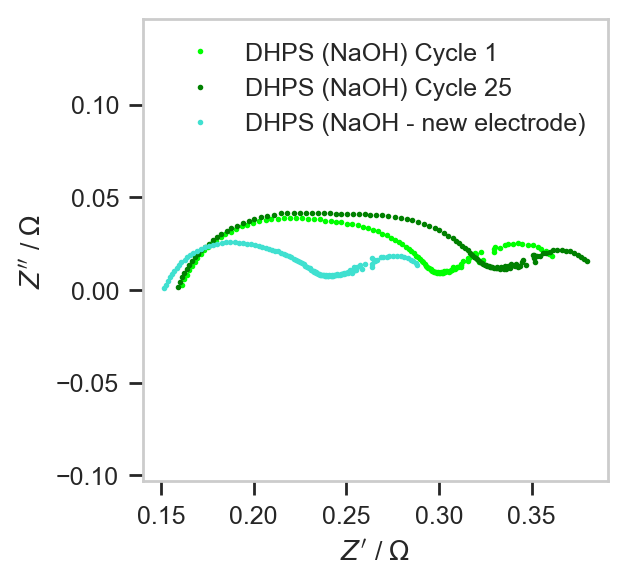

In [53]:
EISData_array = []
fitted_EISData_array = []
DRTData_array = []
R_array = []
L_array = []

lambda_0 = 1e-12

color_list= []

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_02_GEIS_C04.mpr"
# label = "DHPS (KOH) Cycle 1"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)
# color_list.append('blue')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_06_GEIS_C04.mpr"
# label = "DHPS (KOH) Cycle 25"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 15) 
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)
# color_list.append('darkblue')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\2_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_newelec_02_GEIS_C04.mpr"
# label = "Cycle 26"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1) 
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)
# color_list.append('midnightblue')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\1_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_02_GEIS_C04.mpr"
label = "DHPS (NaOH) Cycle 1"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1) 
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('lime')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\1_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_06_GEIS_C04.mpr"
label = "DHPS (NaOH) Cycle 25"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 15) 
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('green')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\6_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_newnegotrode_02_GEIS_C04.mpr"
label = "DHPS (NaOH - new electrode)"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1) 
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('turquoise')

NyquistPlot_object = NyquistPlot(figsize=(3, 3), dpi=200) 

for i, EISData_object in enumerate(EISData_array):
    EISData_object.trim_inductive()
    #EISData_object.crop_frequency(1, 8e3)
    EISData_object.crop_frequency(0.1, 2e5)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1, color = color_list[i], zorder = 3)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.05)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
NyquistPlot_object.add_major_ticks(spacing_x = 0.05, spacing_y = 0.05)
NyquistPlot_object.ax.legend()

display(NyquistPlot_object.fig)




### Oxygen

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


[84.70598855 84.75278651 84.75780277 84.72050776 84.74598661 82.67676707
 84.71425534 84.73382335 84.74149659 84.73435393 82.72579052 84.73341361
 84.71994525 84.78996925 84.71394573 82.74578701 84.73686997 84.75160591
 84.77480984 84.75509749 82.80147449 84.73899205 84.72680832 84.69632415
 84.70163314 84.76377262 84.7930504  84.78728227 84.77846895 84.79596662
 84.90066338 84.89871804 84.87165477 84.88411208 84.86682191]
[86.04412873 86.05097371 86.07537548 86.08464395 86.0913446  86.11243718
 86.1061849  86.12752526 86.14906173 86.15059847 86.20744911 86.16892754
 86.10754726 86.17816705 86.15484555 86.17346653 86.18878321 86.17764668
 86.18888107 86.14605911 86.18406705 86.164972   86.16858881 86.17507375
 86.15027844 86.17249423 86.17468725 86.15781797 83.03614795]


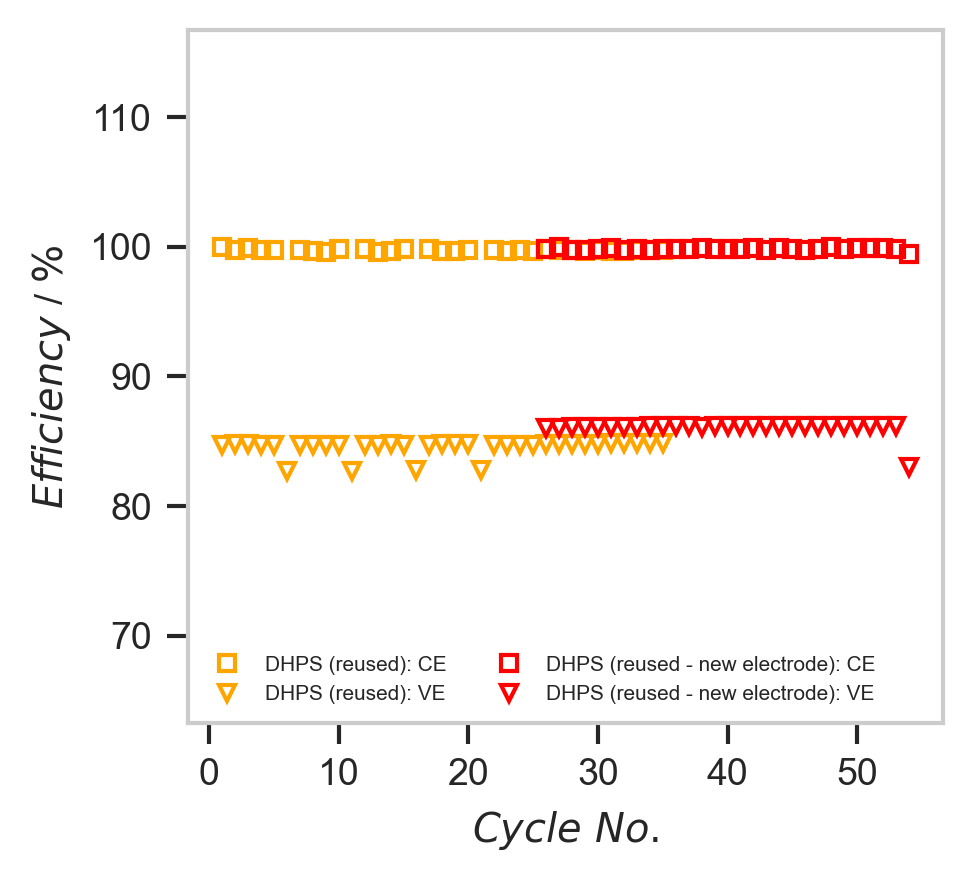

In [59]:
cycling_array = []
color_list = []

j_plot = False

EfficiencyPlot_object = EfficiencyPlot(figsize=(3.25, 3), dpi=300) 

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.27 FB2_DHPS_NR212_FCN_1186HCB\1_FB2_15ml_100mMDHPS_30ml_200mMFCN_22rpm_04_GCPL_C04.mpr"
label="DHPS (reused)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('orange')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.27 FB2_DHPS_NR212_FCN_1186HCB\2_FB2_15ml_100mMDHPS_30ml_200mMFCN_22rpm_newelectrode_04_GCPL_C04.mpr"
label="DHPS (reused - new electrode)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
# had to get rid of incomplete data
# print(ECData_object.columns)
# print(ECData_object.df['half cycle'].unique())
#ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 50)
ECData_object.df['half cycle']+=25*2
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('red')

for i, CyclingData_object in enumerate(cycling_array):
    # if CyclingData_object.label == "DHPS (NaOH) 2":
    #     CyclingData_object.label = ""
    #     #EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    print(CyclingData_object.cycle_data['VE'].to_numpy())
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")
    if Q_plot == True:
        EfficiencyPlot_object.add_Q_discharge(x = CyclingData_object.cycle_data['cycle_number'], Q_discharge = (CyclingData_object.cycle_data['Q_discharge']/3.6), linestyle="", marker="o", markersize = 4, color=color_list[i], label=CyclingData_object.label + ": Q")
if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

if Q_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 1000)

EfficiencyPlot_object.ax.legend(ncols = 2, fontsize = 5)
EfficiencyPlot_object.ax.set_ylim([80, 100])
#EfficiencyPlot_object.ax.set_xlim([0, None])

display(EfficiencyPlot_object.fig)

21.0


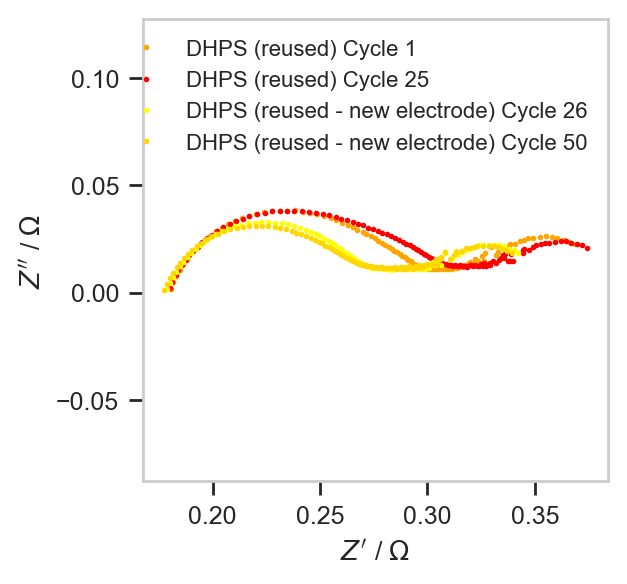

In [66]:

EISData_array = []
fitted_EISData_array = []
DRTData_array = []
R_array = []
L_array = []

lambda_0 = 1e-12

color_list= []

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.27 FB2_DHPS_NR212_FCN_1186HCB\1_FB2_15ml_100mMDHPS_30ml_200mMFCN_22rpm_02_GEIS_C04.mpr"
label = "DHPS (reused) Cycle 1"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('orange')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.27 FB2_DHPS_NR212_FCN_1186HCB\1_FB2_15ml_100mMDHPS_30ml_200mMFCN_22rpm_06_GEIS_C04.mpr"
label = "DHPS (reused) Cycle 25"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 15) 
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('red')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.27 FB2_DHPS_NR212_FCN_1186HCB\2_FB2_15ml_100mMDHPS_30ml_200mMFCN_22rpm_newelectrode_02_GEIS_C04.mpr"
#fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.27 FB2_DHPS_NR212_FCN_1186HCB\2_FB2_15ml_100mMDHPS_30ml_200mMFCN_22rpm_newelectrode_06_GEIS_C04.mpr"
label = "DHPS (reused - new electrode) Cycle 26"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('yellow')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.27 FB2_DHPS_NR212_FCN_1186HCB\2_FB2_15ml_100mMDHPS_30ml_200mMFCN_22rpm_newelectrode_02_GEIS_C04.mpr"
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.27 FB2_DHPS_NR212_FCN_1186HCB\2_FB2_15ml_100mMDHPS_30ml_200mMFCN_22rpm_newelectrode_06_GEIS_C04.mpr"
label = "DHPS (reused - new electrode) Cycle 50"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 15)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('gold')

NyquistPlot_object = NyquistPlot(figsize=(3, 3), dpi=200) 

for i, EISData_object in enumerate(EISData_array):
    EISData_object.trim_inductive()
    #EISData_object.crop_frequency(1, 8e3)
    EISData_object.crop_frequency(0.1, 2e5)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1, color = color_list[i], zorder = 3)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.05)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
NyquistPlot_object.add_major_ticks(spacing_x = 0.05, spacing_y = 0.05)
NyquistPlot_object.ax.legend(fontsize = 8)

display(NyquistPlot_object.fig)




# comparison

15.0
15.0


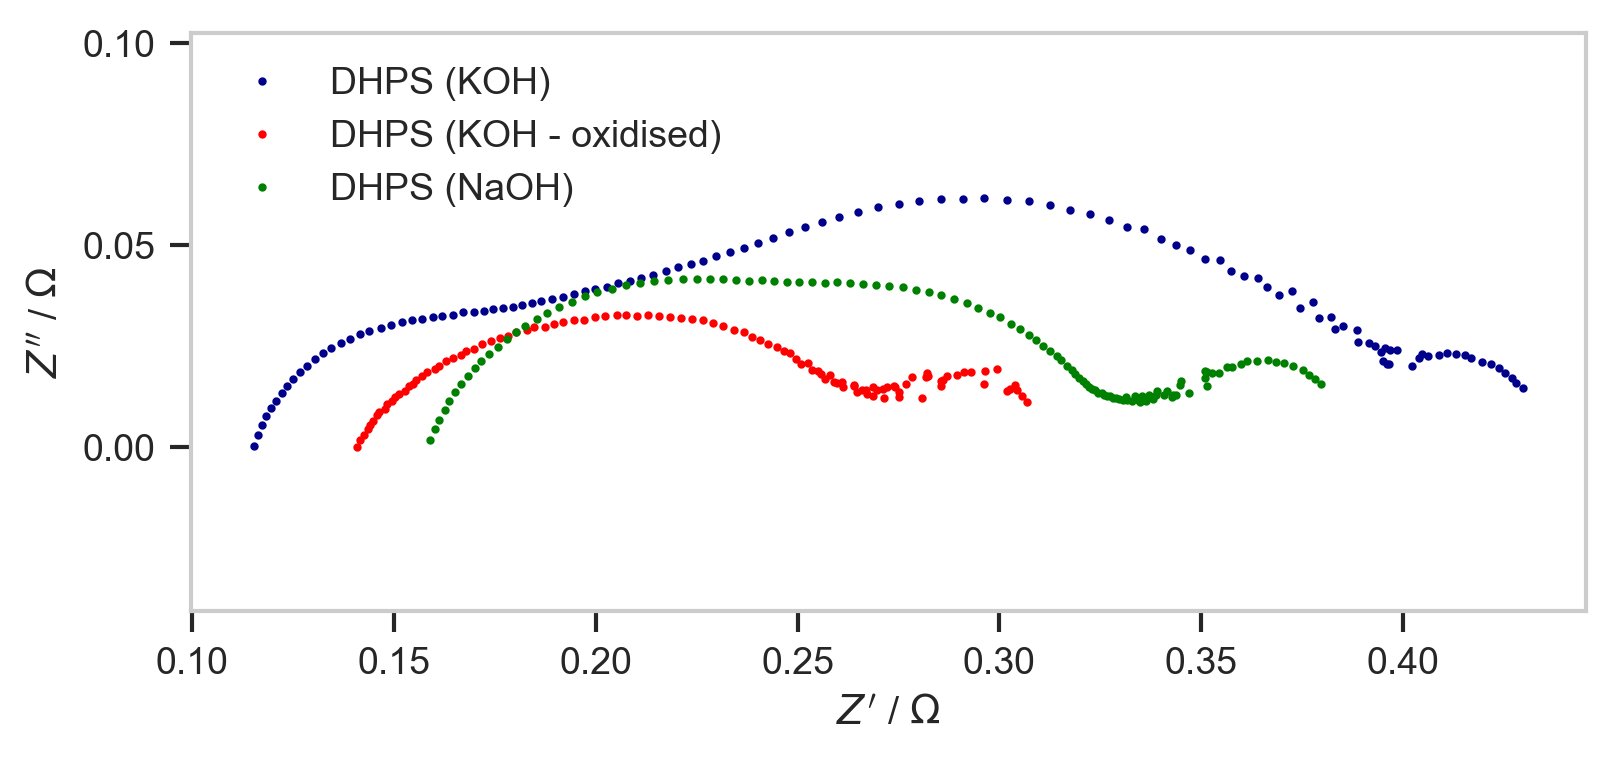

In [8]:
EISData_array = []
fitted_EISData_array = []
DRTData_array = []
R_array = []
L_array = []

lambda_0 = 1e-12

color_list= []

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_02_GEIS_C04.mpr"
# label = "DHPS (KOH) Cycle 1"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)
# color_list.append('blue')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_06_GEIS_C04.mpr"
label = "DHPS (KOH) Cycle 25"
label = "DHPS (KOH)"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 15) 
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('darkblue')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.07.28 FB2_DHPS_400T5h_E620K_FCN_400T5h_1186HCB\2_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_0wash_02_GEIS_C04.mpr"
label = "DHPS (KOH - oxidised) Cycle 25ish"
label = "DHPS (KOH - oxidised)"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('red')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\2_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_newelec_02_GEIS_C04.mpr"
# label = "Cycle 26"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1) 
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)
# color_list.append('midnightblue')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\1_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_02_GEIS_C04.mpr"
# label = "DHPS (NaOH) Cycle 1"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1) 
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)
# color_list.append('lime')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\1_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_06_GEIS_C04.mpr"
label = "DHPS (NaOH) Cycle 25"
label = "DHPS (NaOH)"
ECData_object = BiologicLoader().load_data(fpath=fpath)
print(max(ECData_object.df["cycle number"]))
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 15) 
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)
color_list.append('green')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\6_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_newnegotrode_02_GEIS_C04.mpr"
# label = "DHPS (NaOH - new electrode)"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(max(ECData_object.df["cycle number"]))
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1) 
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)
# color_list.append('turquoise')

NyquistPlot_object = NyquistPlot(figsize=(6, 2.5), dpi=300) 

for i, EISData_object in enumerate(EISData_array):
    EISData_object.trim_inductive()
    #EISData_object.crop_frequency(1, 8e3)
    EISData_object.crop_frequency(0.1, 2e5)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1, color = color_list[i], zorder = 3)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.05)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
NyquistPlot_object.add_major_ticks(spacing_x = 0.05, spacing_y = 0.05)
NyquistPlot_object.ax.legend()

display(NyquistPlot_object.fig)


